1. Time-Series Analysis
 Understand:

* trends
* seasonality
* stationarity
* temporal dependencies
2. Statistical Forecasting Diagnostics

Using:

* ADF Test
* KPSS Test
* ACF
* PACF
3. Prophet Optimization

Tune:

* changepoints
* seasonality
* forecasting behavior
4. Forecasting Intelligence

Prepare data for:

* LSTM
* Temporal Fusion Transformer
* hybrid ensemble models

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
daily_sales = pd.read_csv(
    "../Data/processed/daily_sales_features.csv"
)

In [3]:
ts = daily_sales.groupby(
    'InvoiceDate'
)['Quantity'].sum()

In [4]:
ts.index = pd.to_datetime(ts.index)

In [5]:
ts = ts.sort_index()

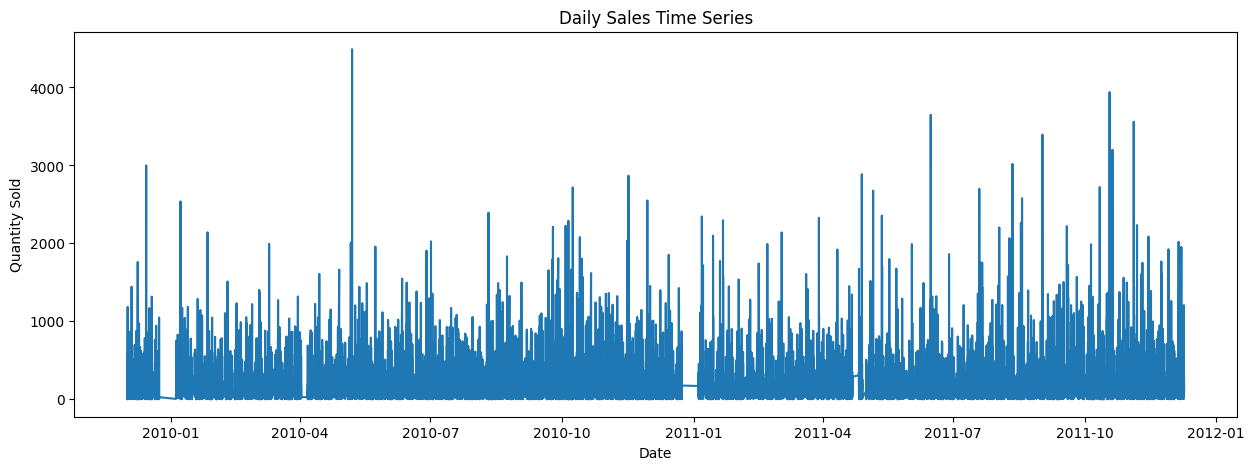

In [6]:
plt.figure(figsize=(15,5))

plt.plot(ts)

plt.title("Daily Sales Time Series")

plt.xlabel("Date")

plt.ylabel("Quantity Sold")

plt.show()

## Look for:

* upward/downward trend
* repeating patterns
* spikes
* seasonality

This is the foundation of demand forecasting.

# STATIONARITY TESTING
### What is Stationarity?

### A stationary series has:

* constant mean
* constant variance
* stable patterns over time

Most classical forecasting models require stationarity.

In [7]:
from statsmodels.tsa.stattools import adfuller

In [8]:
adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])

print("p-value:", adf_result[1])

ADF Statistic: -33.32314029534596
p-value: 0.0


| p-value | Meaning        |
| ------- | -------------- |
| < 0.05  | Stationary     |
| > 0.05  | Non-stationary |


In [10]:
from statsmodels.tsa.stattools import kpss

In [11]:
kpss_result = kpss(ts)

print("KPSS Statistic:", kpss_result[0])

print("p-value:", kpss_result[1])

KPSS Statistic: 5.431215024012899
p-value: 0.01


C:\Users\uttam\AppData\Local\Temp\ipykernel_13856\2369687594.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts)


In [12]:
ts_diff = ts.diff().dropna()

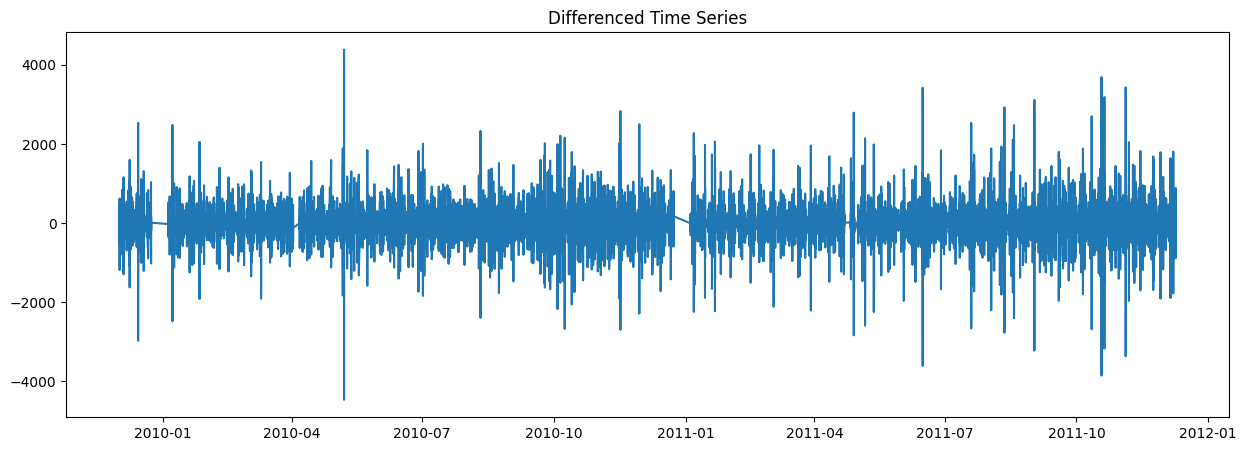

In [13]:
plt.figure(figsize=(15,5))

plt.plot(ts_diff)

plt.title("Differenced Time Series")

plt.show()

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=30
)

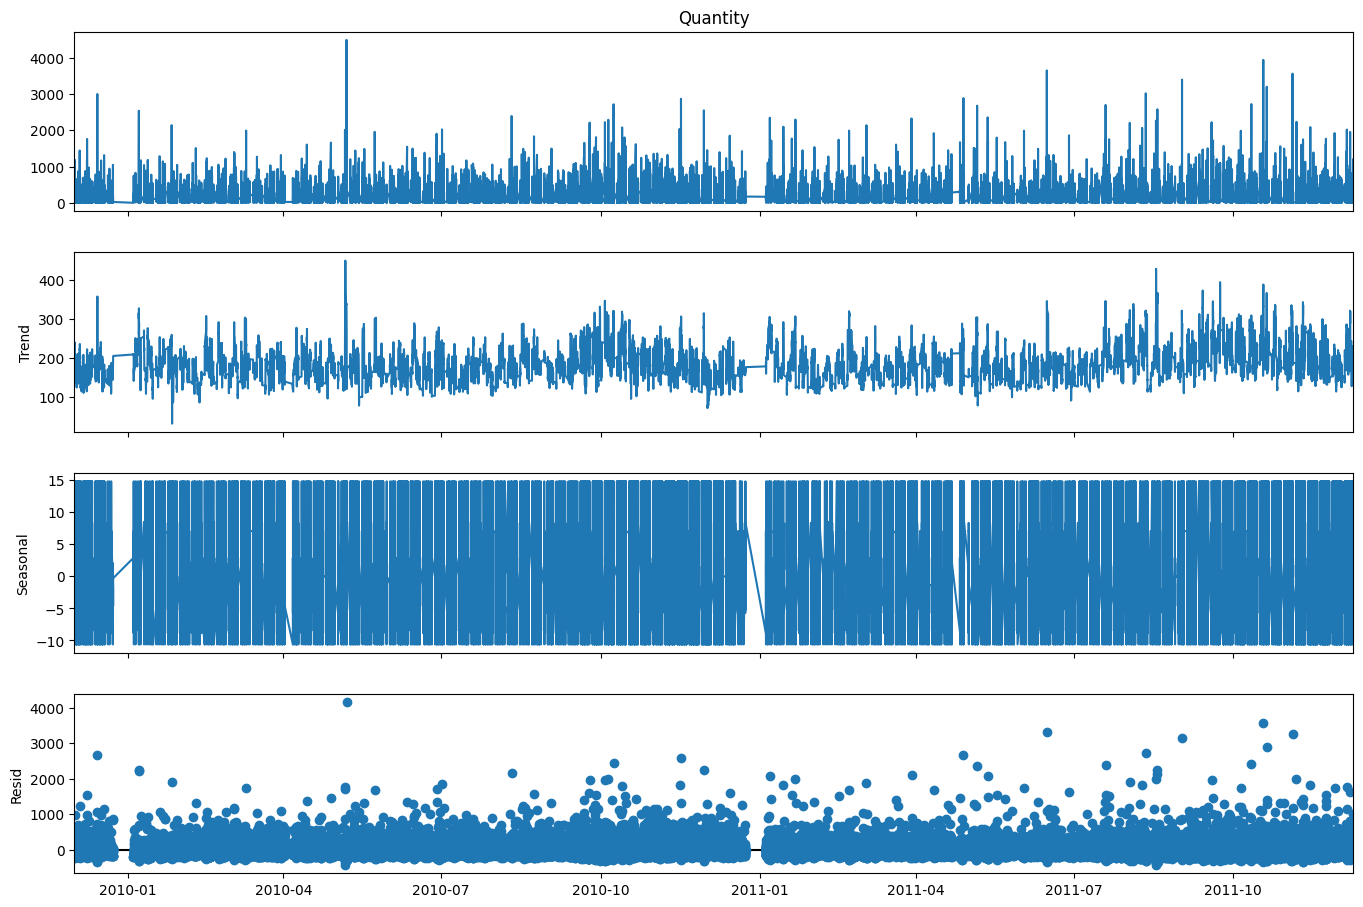

In [16]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

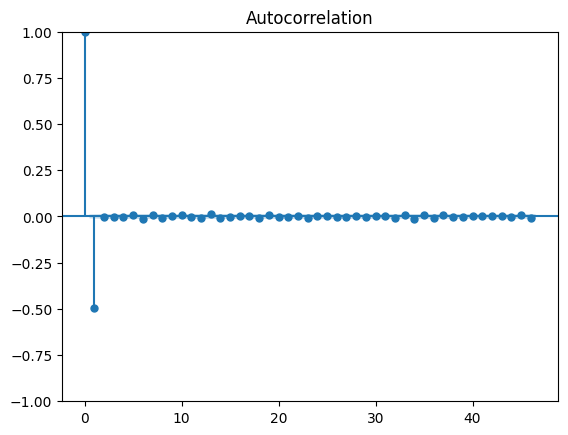

In [18]:
plot_acf(ts_diff)

plt.show()

In [19]:
from statsmodels.graphics.tsaplots import plot_pacf

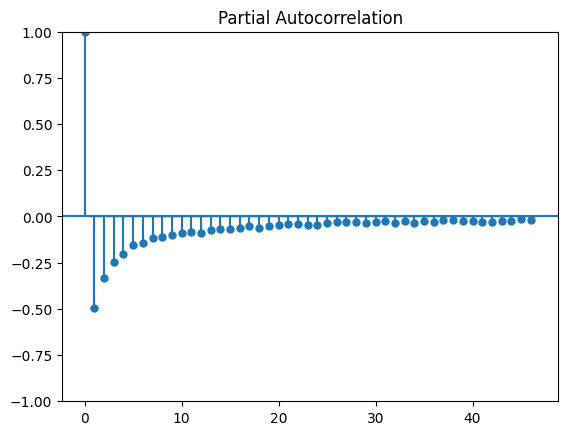

In [20]:
plot_pacf(ts_diff)

plt.show()

In [21]:
prophet_df = ts.reset_index()

prophet_df.columns = ['ds','y']

In [23]:
from prophet import Prophet

In [24]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,
    seasonality_mode='multiplicative'
)

In [25]:
model.fit(prophet_df)

22:37:36 - cmdstanpy - INFO - Chain [1] start processing
22:37:44 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = model.make_future_dataframe(
    periods=30
)

In [27]:
forecast = model.predict(future)

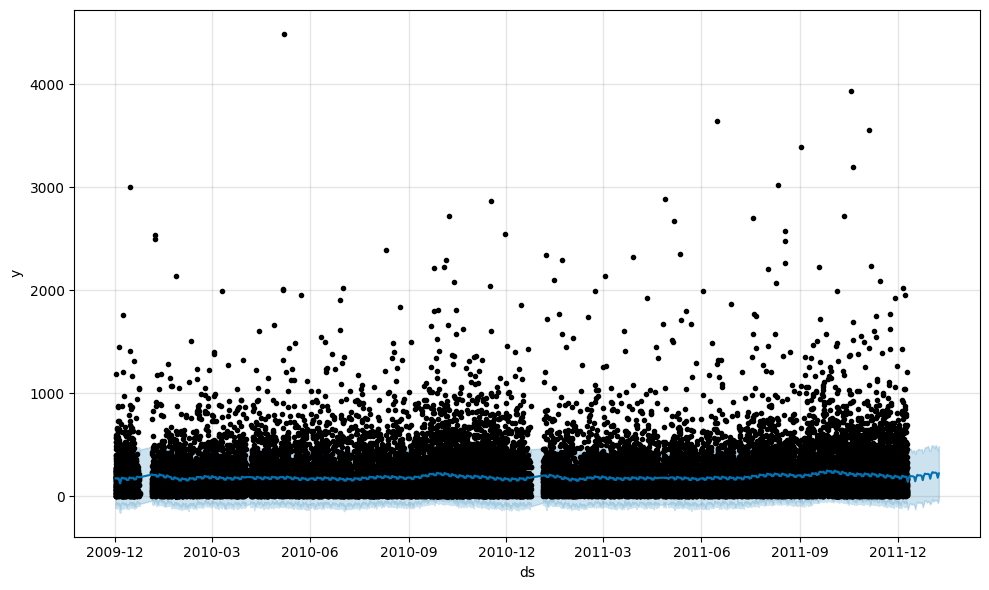

In [28]:
fig = model.plot(forecast)

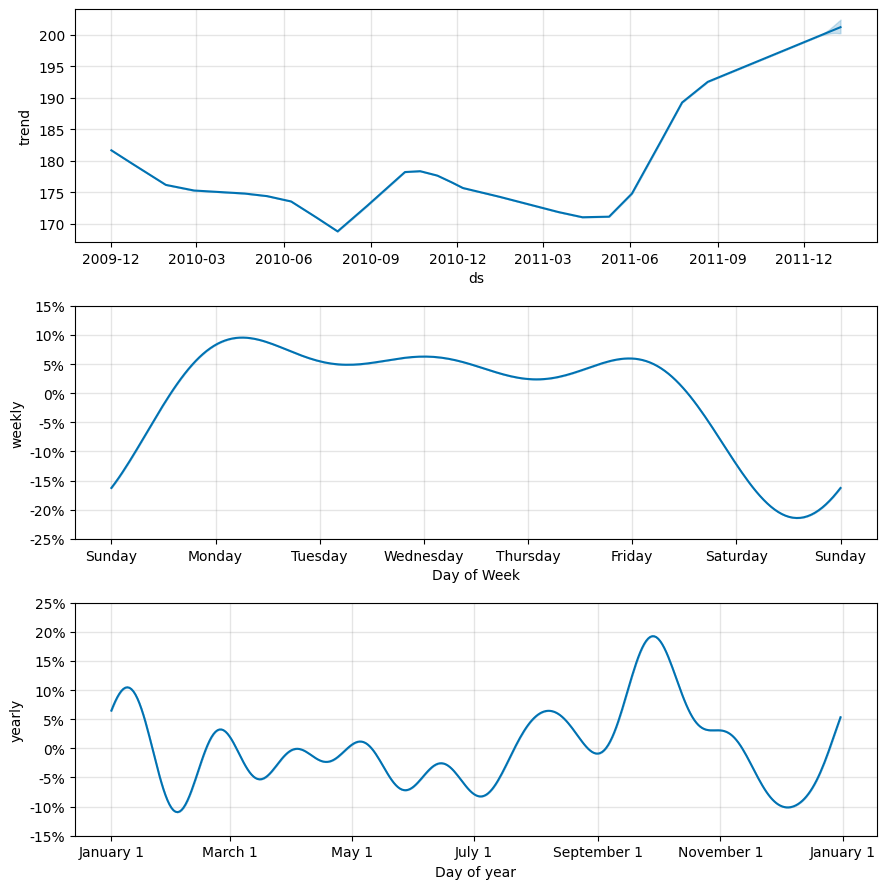

In [29]:
fig2 = model.plot_components(forecast)

In [ ]:
## What Components Show
### Trend

* business growth

### Weekly seasonality

* shopping behavior

### Yearly seasonality

festive/business cycles